# Actividad 7: Redes Neuronales Artificiales
# Ramiro Emiliano Martinez De La Cruz - 2014197 - Martes N4
# María Fernanda Garza Barbosa - 1945003 - Martes N4
# Karla Judith Corona Castro - 1923390 - Martes N4
# Abraham Giovanni Aguirre Bravo  2014222 - N4

# Librerias


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist
import random

# Cargar datos

In [ ]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

# Preprocesar los datos

In [ ]:
# Normalizar valores de píxeles
train_data = train_data / 255.0
test_data = test_data / 255.0

# Aplanar imágenes (28x28 -> 784)
train_data = train_data.reshape(-1, 784)
test_data = test_data.reshape(-1, 784)


# Selección y entrenamiento del modelo.

In [ ]:
# Definir la red neuronal artificial prealimentada
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # Estructura propuesta: dos capas ocultas
    activation='relu',             # Función de activación en capas ocultas
    solver='adam',                 # Optimizador
    max_iter=20,                   # Número de épocas (iteraciones)
    random_state=42
)
# Entrenar la red con los datos de entrenamiento
mlp.fit(train_data, train_labels)

# Evaluar el modelo con los datos de prueba
predicciones = mlp.predict(test_data)
exactitud = accuracy_score(test_labels, predicciones)
print(f"\n✅ Exactitud del modelo en el conjunto de prueba: {exactitud:.4f}")



✅ Exactitud del modelo en el conjunto de prueba: 0.9769


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


# Prueba del modelo.


🎯 Predicciones aleatorias:


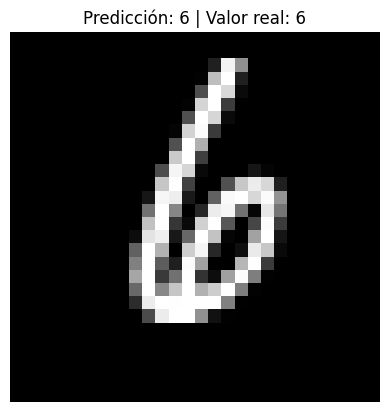

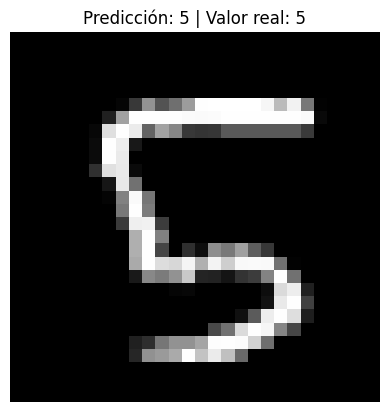

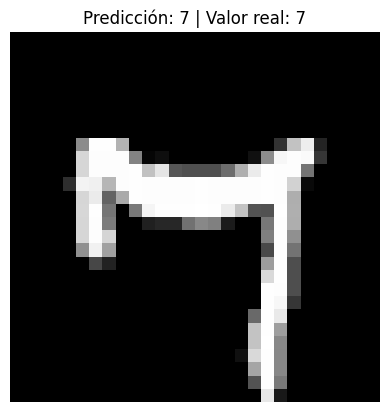

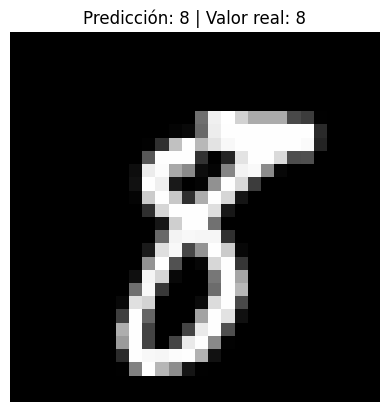

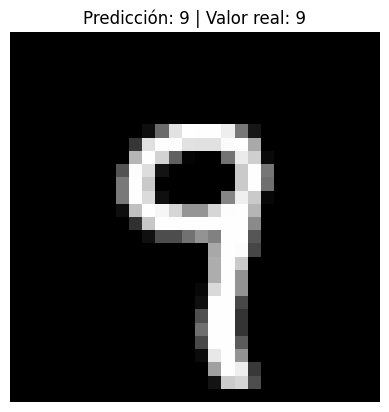

In [ ]:
# Seleccionar 5 índices aleatorios
indices_aleatorios = random.sample(range(len(test_data)), 5)

# Mostrar predicciones aleatorias
print("\n🎯 Predicciones aleatorias:")
for i in indices_aleatorios:
    imagen = test_data[i].reshape(28, 28)
    pred = mlp.predict([test_data[i]])[0]
    real = test_labels[i]

    plt.imshow(imagen, cmap='gray')
    plt.title(f"Predicción: {pred} | Valor real: {real}")
    plt.axis('off')
    plt.show()
